# Feature Engineering: Text Representation

Raw text data cannot be fed directly into machine learning models. Algorithms require structured numerical inputs to perform mathematical operations, identify patterns, and make predictions. 

Feature engineering translates natural language into dense or sparse numerical vectors. This notebook covers the evolution of text vectorisation, starting with basic frequency models and moving up to context-aware semantic spaces.

### Explored Techniques

* **Bag of Words (BoW):** Maps word frequencies while ignoring sequence.
* **TF-IDF:** Evaluates word importance by penalising common terms.
* **Word Embeddings:** Captures semantic meaning in dense vectors.

### Why it Matters
The choice of vectorisation strategy directly dictates your model's capacity to learn. Poor feature representation caps model performance, regardless of how complex your downstream classifier is.


<h1 align="center" style="color: #2E5B88;">Feature Engineering for Machine Learning </h1>


In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import TruncatedSVD

In [2]:
df = pd.read_parquet("data/processed/reviews_after_preprocessing.parquet")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 674523 entries, 0 to 674522
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             674523 non-null  int64         
 1   images             674523 non-null  object        
 2   asin               674523 non-null  object        
 3   parent_asin        674523 non-null  object        
 4   user_id            674523 non-null  object        
 5   timestamp          674523 non-null  datetime64[ns]
 6   helpful_vote       674523 non-null  int64         
 7   verified_purchase  674523 non-null  bool          
 8   review             674523 non-null  object        
 9   sentiment          674523 non-null  object        
 10  char_length        674523 non-null  int64         
 11  word_count         674523 non-null  int64         
 12  sentence_count     674523 non-null  int64         
 13  year               674523 non-null  int32   

## Dataset Preparation

In [4]:
# Original text (Deep Learning)
X_dl = df["dl_review"]
# Cleaned text (Machine Learning)
X_ml = df["clean_review"]

In [5]:
meta_features = [
    "helpful_vote",
    "verified_purchase",
    "char_length",
    "word_count",
    "sentence_count"
]

X_meta = df[meta_features].copy()

# Convert boolean to integer
X_meta["verified_purchase"] = X_meta["verified_purchase"].astype(int)

y = df["sentiment"]

print(y.value_counts())

sentiment
Positive    480076
Negative    139832
Neutral      54615
Name: count, dtype: int64


## Train-Test Split for ML

In [6]:
X_train_text, X_test_text, \
X_train_meta, X_test_meta, \
y_train, y_test = train_test_split(
    X_ml,
    X_meta,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [7]:
print("------- Dataset Shapes --------")
print(f"X_train_text shape: {X_train_text.shape}")  
print(f"X_test_text shape:  {X_test_text.shape}") 
print("-"*32)
print(f"X_train_meta shape: {X_train_meta.shape}")  
print(f"X_test_meta shape:  {X_test_meta.shape}") 
print("-"*32)
print(f"y_train shape:      {y_train.shape}")       
print(f"y_test shape:       {y_test.shape}")  
print("-"*32)


------- Dataset Shapes --------
X_train_text shape: (539618,)
X_test_text shape:  (134905,)
--------------------------------
X_train_meta shape: (539618, 5)
X_test_meta shape:  (134905, 5)
--------------------------------
y_train shape:      (539618,)
y_test shape:       (134905,)
--------------------------------


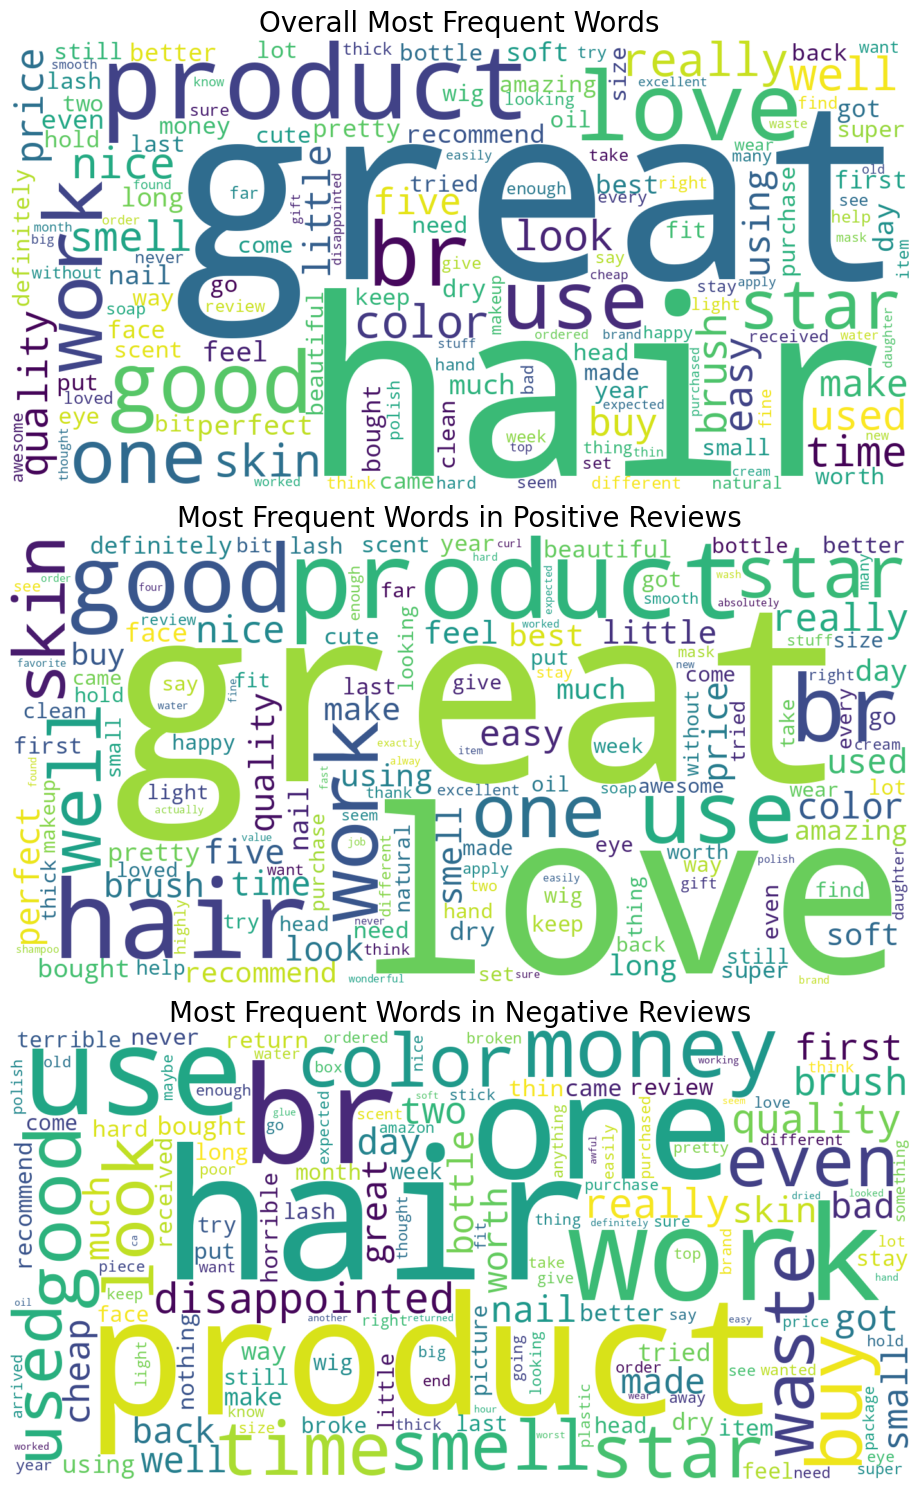

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Change this to your actual preprocessed column name
text_col = "clean_review"

# Remove missing values
df[text_col] = df[text_col].fillna("").astype(str)

# Create sentiment labels if you haven't already
df["sentiment"] = df["rating"].apply(
    lambda x: "Negative" if x <= 2
    else "Neutral" if x == 3
    else "Positive"
)

# ------------------------------------------------
# 1. Overall Word Cloud
# ------------------------------------------------

all_text = " ".join(df[text_col])

wordcloud_all = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=150,
    collocations=False
).generate(all_text)


# ------------------------------------------------
# 2. Positive Word Cloud
# ------------------------------------------------

positive_text = " ".join(
    df.loc[df["sentiment"] == "Positive", text_col]
)

wordcloud_positive = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=150,
    collocations=False
).generate(positive_text)


# ------------------------------------------------
# 3. Negative Word Cloud
# ------------------------------------------------

negative_text = " ".join(
    df.loc[df["sentiment"] == "Negative", text_col]
)

wordcloud_negative = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=150,
    collocations=False
).generate(negative_text)


# ------------------------------------------------
# Display
# ------------------------------------------------

plt.figure(figsize=(18, 15))

plt.subplot(3, 1, 1)
plt.imshow(wordcloud_all, interpolation="bilinear")
plt.axis("off")
plt.title("Overall Most Frequent Words", fontsize=20)

plt.subplot(3, 1, 2)
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Positive Reviews", fontsize=20)

plt.subplot(3, 1, 3)
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Negative Reviews", fontsize=20)

plt.tight_layout()
plt.show()

In [8]:
bow = CountVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5
)

X_train_bow = bow.fit_transform(X_train_text)

X_test_bow = bow.transform(X_test_text)

print(X_train_bow.shape)
print(X_test_bow.shape)

(539618, 10000)
(134905, 10000)


In [9]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train_text)

X_test_tfidf = tfidf.transform(X_test_text)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(539618, 10000)
(134905, 10000)


In [38]:
selector = SelectKBest(chi2, k=5000)
X_train_tfidf_sel = selector.fit_transform(X_train_tfidf, y_train)
X_test_tfidf_sel  = selector.transform(X_test_tfidf)

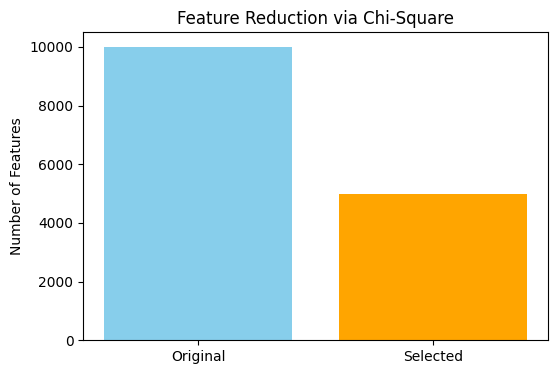

In [11]:
# Plot number of selected features
plt.figure(figsize=(6,4))
plt.bar(['Original', 'Selected'], [X_train_tfidf.shape[1], X_train_tfidf_sel.shape[1]], color=['skyblue','orange'])
plt.title('Feature Reduction via Chi‑Square')
plt.ylabel('Number of Features')
plt.show()

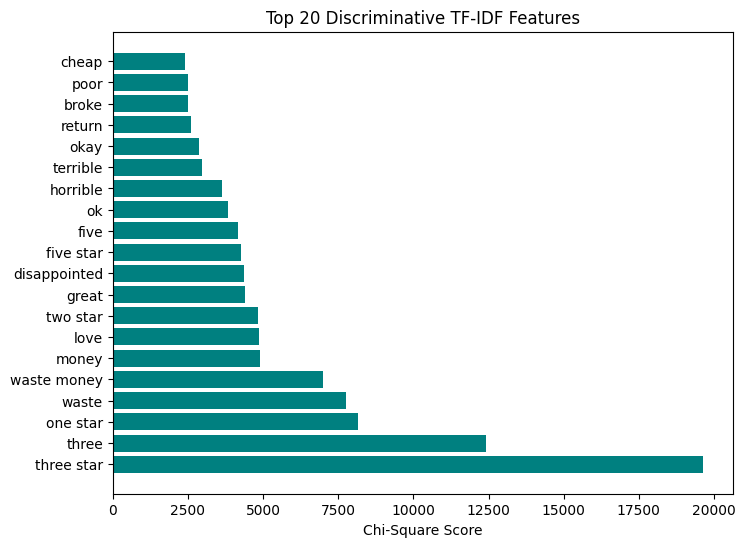

In [12]:
feature_scores = selector.scores_
feature_names = np.array(tfidf.get_feature_names_out())
top_indices = np.argsort(feature_scores)[-20:]
top_features = feature_names[top_indices]
top_scores = feature_scores[top_indices]

plt.figure(figsize=(8,6))
plt.barh(top_features, top_scores, color='teal')
plt.title('Top 20 Discriminative TF‑IDF Features')
plt.xlabel('Chi‑Square Score')
plt.gca().invert_yaxis()
plt.show()


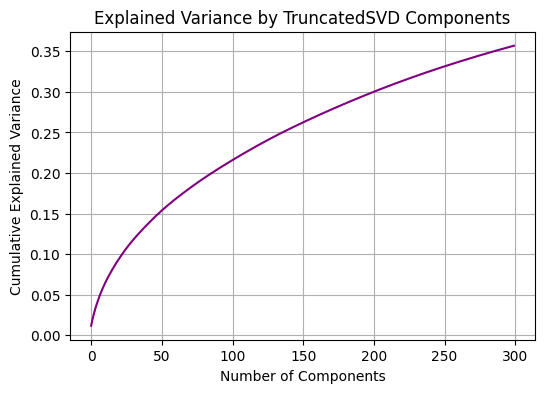

In [13]:
svd = TruncatedSVD(n_components=300, random_state=42)
X_train_tfidf_svd = svd.fit_transform(X_train_tfidf)
X_test_tfidf_svd  = svd.transform(X_test_tfidf)

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(svd.explained_variance_ratio_), color='purple')
plt.title('Explained Variance by TruncatedSVD Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


In [14]:
explained_var = np.cumsum(svd.explained_variance_ratio_)
for i in [50, 100, 200, 300]:
    print(f"{i} components → {explained_var[i-1]:.2f} variance retained")


50 components → 0.15 variance retained
100 components → 0.21 variance retained
200 components → 0.30 variance retained
300 components → 0.36 variance retained


In [40]:
X_train_meta_sparse = csr_matrix(X_train_meta.values)
X_test_meta_sparse  = csr_matrix(X_test_meta.values)

X_train_hybrid = hstack([X_train_tfidf_sel, X_train_meta_sparse])
X_test_hybrid  = hstack([X_test_tfidf_sel, X_test_meta_sparse])

print("Hybrid feature shape:", X_train_hybrid.shape)
print("Sparsity:", 1 - (X_train_hybrid.nnz / (X_train_hybrid.shape[0] * X_train_hybrid.shape[1])))


Hybrid feature shape: (539618, 5005)
Sparsity: 0.9961486160137799


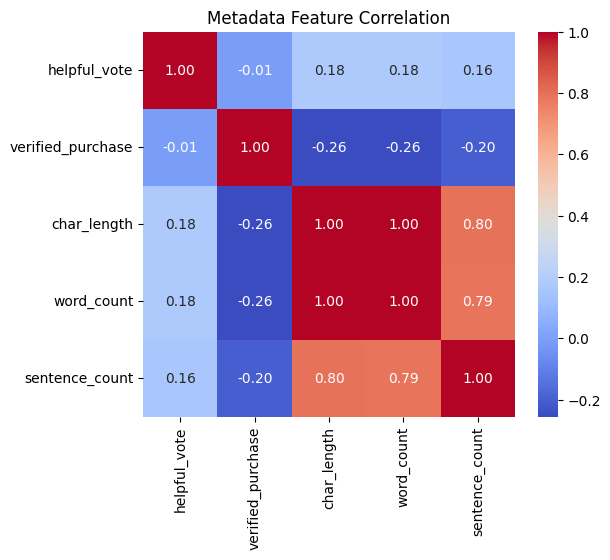

In [16]:
corr = X_train_meta.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Metadata Feature Correlation')
plt.show()


In [17]:
corr_matrix = X_train_meta.corr().abs()

# Find correlations above 0.8
high_corr = [(i,j) for i in corr_matrix.columns for j in corr_matrix.columns 
             if i != j and corr_matrix.loc[i,j] > 0.8]

print("Highly correlated pairs:", high_corr)

# Drop redundant features 
X_train_meta_reduced = X_train_meta.drop(columns=['char_length','sentence_count'])
X_test_meta_reduced  = X_test_meta.drop(columns=['char_length','sentence_count'])


Highly correlated pairs: [('char_length', 'word_count'), ('word_count', 'char_length')]


In [83]:
X_train_meta_sparse = csr_matrix(X_train_meta_reduced.values)
X_test_meta_sparse  = csr_matrix(X_test_meta_reduced.values)

X_train_hybrid = hstack([X_train_tfidf_sel, X_train_meta_sparse])
X_test_hybrid  = hstack([X_test_tfidf_sel, X_test_meta_sparse])

joblib.dump(X_train_tfidf, "artifacts/machine_learning/X_train_tfidf.pkl")          # original TF-IDF
joblib.dump(X_test_tfidf, "artifacts/machine_learning/X_test_tfidf.pkl")
joblib.dump(X_train_tfidf_sel, "artifacts/machine_learning/X_train_tfidf_sel.pkl")  # selected TF-IDF
joblib.dump(X_test_tfidf_sel, "artifacts/machine_learning/X_test_tfidf_sel.pkl")
joblib.dump(X_train_tfidf_svd, "artifacts/machine_learning/X_train_tfidf_svd.pkl")  # reduced TF-IDF
joblib.dump(X_test_tfidf_svd, "artifacts/machine_learning/X_test_tfidf_svd.pkl")
joblib.dump(X_train_hybrid, "artifacts/machine_learning/X_train_hybrid.pkl")        # hybrid (TF-IDF + metadata)
joblib.dump(X_test_hybrid, "artifacts/machine_learning/X_test_hybrid.pkl")
joblib.dump(y_train,"artifacts/machine_learning/y_train.pkl")                               # target
joblib.dump(y_test,"artifacts/machine_learning/y_test.pkl")                               

['artifacts/machine_learning/y_test.pkl']

In [19]:
# Print shapes
print("============================================================")
print("Feature Engineering Data Shapes")
print("============================================================")
print(f"Training Samples : {X_train_tfidf.shape[0]}")
print(f"Testing Samples  : {X_test_tfidf.shape[0]}")
print("------------------------------------------------------------")
print(f"Original TF-IDF  : {X_train_tfidf.shape}")
print(f"TF-IDF Selected  : {X_train_tfidf_sel.shape}")
print(f"TF-IDF SVD       : {X_train_tfidf_svd.shape}")
print(f"Hybrid Features  : {X_train_hybrid.shape}")
print("------------------------------------------------------------")
print(f"Labels (train)   : {y_train.shape}")
print(f"Labels (test)    : {y_test.shape}")
print("============================================================")

Feature Engineering Data Shapes
Training Samples : 539618
Testing Samples  : 134905
------------------------------------------------------------
Original TF-IDF  : (539618, 10000)
TF-IDF Selected  : (539618, 5000)
TF-IDF SVD       : (539618, 300)
Hybrid Features  : (539618, 5003)
------------------------------------------------------------
Labels (train)   : (539618,)
Labels (test)    : (134905,)


<h1 align="center" style="color: #2E5B88;">Feature Engineering for Deep Learning Models</h1>


In [74]:
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 674523 entries, 0 to 674522
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             674523 non-null  int64         
 1   images             674523 non-null  object        
 2   asin               674523 non-null  object        
 3   parent_asin        674523 non-null  object        
 4   user_id            674523 non-null  object        
 5   timestamp          674523 non-null  datetime64[ns]
 6   helpful_vote       674523 non-null  int64         
 7   verified_purchase  674523 non-null  bool          
 8   review             674523 non-null  object        
 9   sentiment          674523 non-null  object        
 10  char_length        674523 non-null  int64         
 11  word_count         674523 non-null  int64         
 12  sentence_count     674523 non-null  int64         
 13  year               674523 non-null  int32   

## Dataset Preparation

In [52]:
print(f"Number of reviews : {len(X_dl):,}")
print(f"Number of labels  : {len(y):,}")
print(y.value_counts())

Number of reviews : 674,523
Number of labels  : 674,523
sentiment
Positive    480076
Negative    139832
Neutral      54615
Name: count, dtype: int64


## Train-Test Split for DL

In [53]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl,
    y,
    test_size=0.20,
    stratify=y_dl,
    random_state=42
)

print("Training Samples :", len(X_train_dl))
print("Testing Samples  :", len(X_test_dl))

Training Samples : 539618
Testing Samples  : 134905


In [54]:
X_train_dl.head()

337384    great for chemically lightened hair! this is g...
228073    handy cute, but take some time to figure out. ...
415218                                           five stars
626152    it worked great everything was nice hahaha teehee
639178    did not like no,liked. it doesn't do what it p...
Name: dl_review, dtype: object

## Vocabulary Analysis

In [55]:
all_words = " ".join(X_train_dl).split()

word_counts = Counter(all_words)

print("Total Tokens        :", len(all_words))
print("Unique Vocabulary   :", len(word_counts))

Total Tokens        : 20193413
Unique Vocabulary   : 261703


In [56]:
top_words = (
    pd.DataFrame(
        word_counts.most_common(20),
        columns=["Word", "Frequency"]
    )
)

top_words

,Word,Frequency
0,the,781090
1,i,708177
2,and,586305
3,it,492881
4,a,450872
5,to,443212
6,my,319603
7,this,318062
8,for,291179
9,is,280237


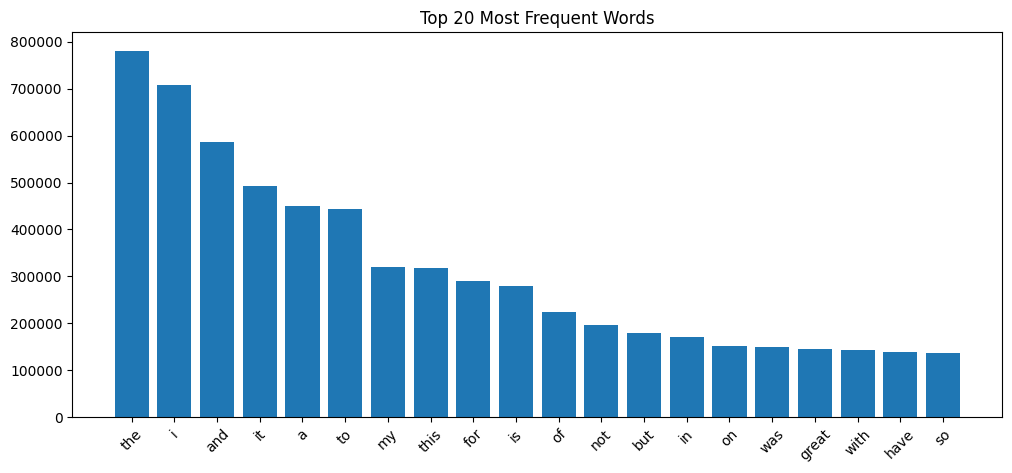

In [57]:
plt.figure(figsize=(12,5))
plt.bar(top_words["Word"], top_words["Frequency"])
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

## Review Length Analysis

In [58]:
review_lengths = X_train_dl.str.split().apply(len)

review_lengths.describe()

count    539618.000000
mean         37.421682
std          47.210542
min           1.000000
25%          12.000000
50%          24.000000
75%          46.000000
max        2591.000000
Name: dl_review, dtype: float64

In [59]:
print(f"Average Length : {review_lengths.mean():.2f}")
print(f"Median Length  : {review_lengths.median():.0f}")
print(f"95 Percentile  : {np.percentile(review_lengths,95):.0f}")
print(f"99 Percentile  : {np.percentile(review_lengths,99):.0f}")
print(f"Maximum Length : {review_lengths.max()}")

Average Length : 37.42
Median Length  : 24
95 Percentile  : 113
99 Percentile  : 224
Maximum Length : 2591


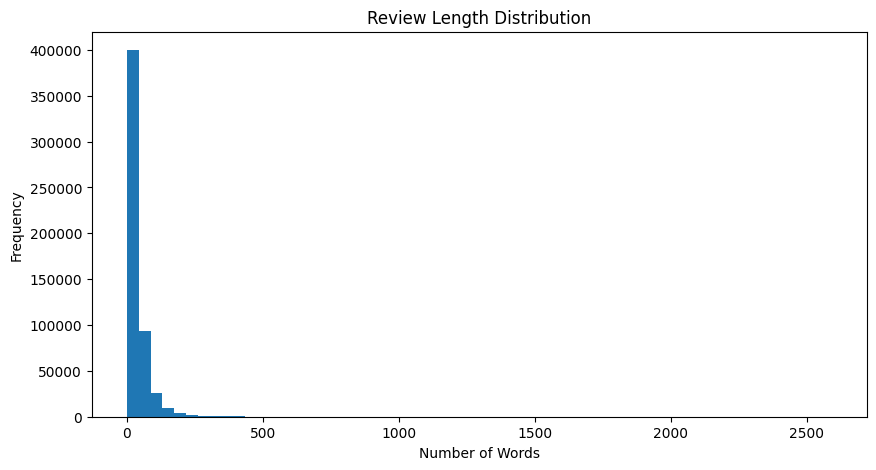

In [60]:
plt.figure(figsize=(10,5))
plt.hist(review_lengths, bins=60)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# ==========================
# Tokenizer Configuration
# ==========================

VOCAB_SIZE = 30000
MAX_SEQUENCE_LENGTH = 128
EMBEDDING_DIM = 128
OOV_TOKEN = "<OOV>"

## Tokenizer Configuration

The tokenizer hyperparameters were selected based on an analysis of the training corpus.

The training data contains approximately **20.2 million tokens** with **261,703 unique words**. Following Zipf's Law, a large proportion of the vocabulary consists of infrequent words that contribute little to model performance while substantially increasing memory requirements. Therefore, the vocabulary size is limited to the **30,000** most frequent words.

Review length analysis shows that **95%** of the reviews contain **113 words or fewer**. To efficiently capture the majority of the dataset while minimizing unnecessary padding, the maximum sequence length is set to **128 tokens**.

An Out-of-Vocabulary (OOV) token is also introduced to represent words that are not included in the selected vocabulary, improving the model's ability to handle unseen words during inference.

## Tokenization

In [61]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train_dl)

print(f"Vocabulary Learned : {len(tokenizer.word_index):,}")

Vocabulary Learned : 94,556


In [62]:
X_train_seq = tokenizer.texts_to_sequences(X_train_dl)
X_test_seq = tokenizer.texts_to_sequences(X_test_dl)

In [63]:
sample_idx = 0

print("Original Review:\n")
print(X_train_dl.iloc[sample_idx])

print("\nSequence:\n")
print(X_train_seq[sample_idx])

Original Review:

great for chemically lightened hair! this is great. it works very well to soften hair. i bleach my hair and i love this product because it doesn't have harsh chemicals in it, which can cause further damage. i recommend this product, if you have damaged hair! it does have a slight odor though, which reminds me of a freshly mowed lawn. this is probably from the broccoli oil. it's not very noticeable though...

Sequence:

[16, 10, 4189, 4671, 17, 8, 11, 16, 5, 53, 25, 40, 7, 2199, 17, 3, 1478, 9, 17, 4, 3, 26, 8, 21, 84, 5, 133, 24, 1248, 1136, 15, 5, 117, 72, 750, 2115, 969, 3, 95, 8, 21, 51, 27, 24, 776, 17, 5, 80, 24, 6, 1135, 862, 249, 117, 1943, 49, 12, 6, 4616, 1, 8136, 8, 11, 434, 76, 2, 15142, 178, 56, 13, 25, 1103, 249]


## Sequence Length Analysis After Tokenization

After fitting the tokenizer, each review is converted into a sequence of integer indices representing words in the learned vocabulary.

Before applying padding and truncation, the distribution of tokenized sequence lengths is analyzed to verify that the selected maximum sequence length efficiently captures the majority of reviews while minimizing unnecessary computational overhead.

In [66]:
sequence_lengths = [len(seq) for seq in X_train_seq]
sequence_lengths = pd.Series(sequence_lengths)
sequence_lengths.describe()

count    539618.000000
mean         37.444268
std          47.386936
min           1.000000
25%          12.000000
50%          24.000000
75%          46.000000
max        2672.000000
dtype: float64

In [67]:
print(f"Average Length : {sequence_lengths.mean():.2f}")
print(f"Median Length  : {sequence_lengths.median():.0f}")
print(f"95 Percentile  : {np.percentile(sequence_lengths,95):.0f}")
print(f"99 Percentile  : {np.percentile(sequence_lengths,99):.0f}")
print(f"Maximum Length : {sequence_lengths.max()}")

Average Length : 37.44
Median Length  : 24
95 Percentile  : 114
99 Percentile  : 225
Maximum Length : 2672


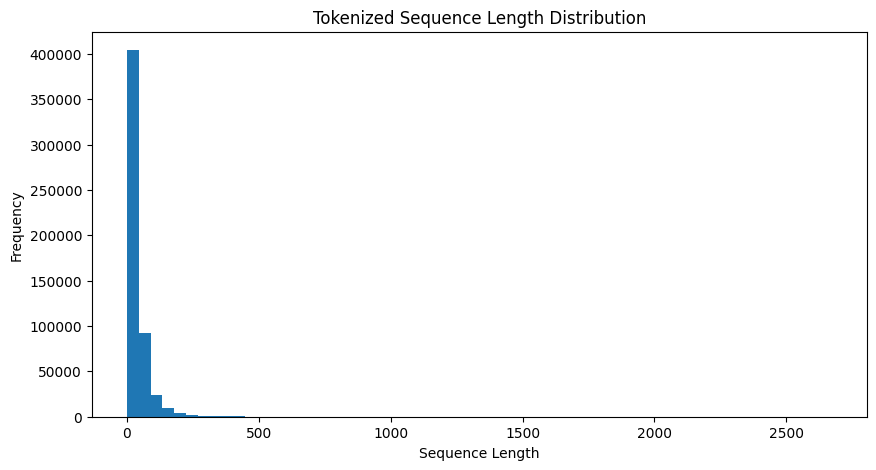

In [68]:
plt.figure(figsize=(10,5))
plt.hist(sequence_lengths, bins=60)
plt.title("Tokenized Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.show()

## Padding

In [70]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

In [71]:
print("Training Shape :", X_train_pad.shape)
print("Testing Shape  :", X_test_pad.shape)

Training Shape : (539618, 128)
Testing Shape  : (134905, 128)


In [73]:
sample_idx = 0

print("Original Review:\n")
print(X_train_dl.iloc[sample_idx])

print("\nSequence:\n")
print(X_train_seq[sample_idx])

print("\nPadded Sequence:\n")
print(X_train_pad[sample_idx])

print("\nSequence Length:", len(X_train_pad[sample_idx]))

Original Review:

great for chemically lightened hair! this is great. it works very well to soften hair. i bleach my hair and i love this product because it doesn't have harsh chemicals in it, which can cause further damage. i recommend this product, if you have damaged hair! it does have a slight odor though, which reminds me of a freshly mowed lawn. this is probably from the broccoli oil. it's not very noticeable though...

Sequence:

[16, 10, 4189, 4671, 17, 8, 11, 16, 5, 53, 25, 40, 7, 2199, 17, 3, 1478, 9, 17, 4, 3, 26, 8, 21, 84, 5, 133, 24, 1248, 1136, 15, 5, 117, 72, 750, 2115, 969, 3, 95, 8, 21, 51, 27, 24, 776, 17, 5, 80, 24, 6, 1135, 862, 249, 117, 1943, 49, 12, 6, 4616, 1, 8136, 8, 11, 434, 76, 2, 15142, 178, 56, 13, 25, 1103, 249]

Padded Sequence:

[   16    10  4189  4671    17     8    11    16     5    53    25    40
     7  2199    17     3  1478     9    17     4     3    26     8    21
    84     5   133    24  1248  1136    15     5   117    72   750  2115
   969  

# Label Encoding

The target variable consists of three categorical sentiment classes:

- Negative
- Neutral
- Positive

Deep learning models require numerical target values rather than text labels. Therefore, the sentiment labels are encoded into integer values using `LabelEncoder`.

The fitted encoder is preserved so that predictions generated by the model can later be converted back to their original sentiment labels during inference.

In [75]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [77]:
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))
mapping

{'Negative': 0, 'Neutral': 1, 'Positive': 2}

In [78]:
print("Training Labels:", y_train_encoded.shape)
print("Testing Labels :", y_test_encoded.shape)

Training Labels: (539618,)
Testing Labels : (134905,)


In [79]:
pd.Series(y_train_encoded).value_counts().sort_index()

0    111866
1     43692
2    384060
Name: count, dtype: int64

### Save Feature Engineering Artifacts

The feature engineering pipeline for the deep learning workflow is now complete.

To ensure reproducibility and enable seamless model training in subsequent notebooks, all required preprocessing artifacts are saved to disk. These artifacts include the fitted tokenizer, label encoder, padded input sequences, encoded target labels, and the tokenizer configuration.

Saving these components allows the deep learning models to be trained and evaluated without repeating the preprocessing pipeline while ensuring consistent text representation during inference and deployment.

In [84]:
DL_ARTIFACT_DIR = "artifacts/deep_learning"
os.makedirs(DL_ARTIFACT_DIR, exist_ok=True)

np.save(f"{DL_ARTIFACT_DIR}/X_train_pad.npy", X_train_pad)

# Save Tokenizer, Label Encoder & Vocabulary
joblib.dump(tokenizer, f"{DL_ARTIFACT_DIR}/dl_tokenizer.pkl")
joblib.dump(label_encoder, f"{DL_ARTIFACT_DIR}/dl_label_encoder.pkl")
joblib.dump(tokenizer.word_index,f"{DL_ARTIFACT_DIR}/word_index.pkl")

# Save padded train & test datasets
np.save(f"{DL_ARTIFACT_DIR}/X_train_pad.npy", X_train_pad)
np.save(f"{DL_ARTIFACT_DIR}/X_test_pad.npy", X_test_pad)
np.save(f"{DL_ARTIFACT_DIR}/y_train.npy", y_train_encoded)
np.save(f"{DL_ARTIFACT_DIR}/y_test.npy", y_test_encoded)

